In [1]:
### PRELUDE
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Add workspace to sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
###

from src.seemps.analysis.mesh import RegularInterval
from src.seemps.analysis.expansion import HermiteExpansion, mps_polynomial_expansion

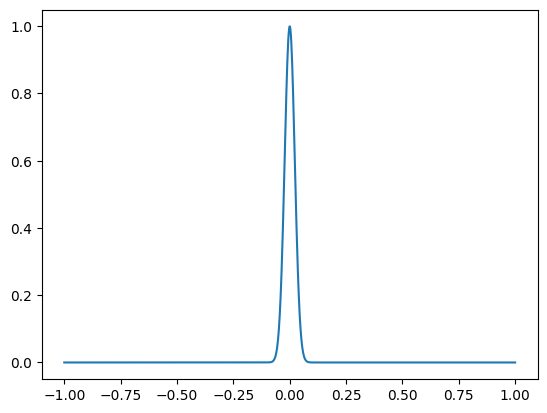

In [2]:
a, b = -1.0, 1.0
n = 10
N = 2**n
interval = RegularInterval(a, b, N, endpoint_right=True)

fn = lambda x: np.exp(-1000 * x**2)

x = interval.to_vector()
y = fn(x)

plt.plot(x, y)

[ 2.70507640e-01 -3.12568232e-22 -6.75984682e-02  7.49891625e-22
  8.44679814e-03 -7.58490182e-23 -7.03690207e-04 -4.05667587e-24
  4.39698686e-05 -2.77403499e-25 -2.19806023e-06  2.90381382e-27
  9.15717375e-08  2.59747016e-28 -3.27004161e-09  8.81967844e-32
  1.02180517e-10 -7.03547371e-32 -2.83820425e-12  2.02000948e-33
  7.09534316e-14]


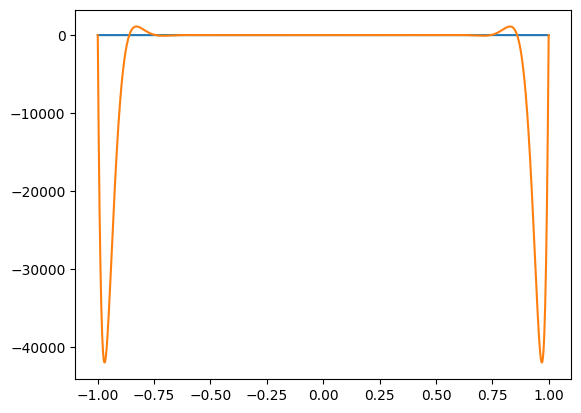

In [3]:
expansion =  HermiteExpansion.project(fn, a, b)
print(expansion.coeffs)

mps = mps_polynomial_expansion(expansion, interval, clenshaw=True)
y_mps = mps.to_vector()

plt.plot(x, y)
plt.plot(x, y_mps)

In [4]:
from scipy.special import factorial

def hermite_expansion(a, d, n_points=1000):
    """
    Compute the Hermite expansion of the function e^{-a x^2} on [-1, 1].
    
    Parameters:
        a (float): Parameter of the Gaussian function.
        d (int): Number of terms in the expansion (degrees 0 to d-1).
        n_points (int): Number of output points in [-1, 1].
    
    Returns:
        numpy.ndarray: Interpolated vector y evaluated at n_points.
    """
    if d <= 0:
        return np.zeros(n_points)
    
    # Calculate required quadrature points (adaptive based on a)
    n_quad = max(100, 2 * d, int(50 * np.sqrt(2 * (a + 1))))
    x_quad, w_quad = np.polynomial.legendre.leggauss(n_quad)
    
    # Precompute Hermite polynomials at quadrature points
    H_quad = np.zeros((d, n_quad))
    H_quad[0] = 1.0
    if d > 1:
        H_quad[1] = 2 * x_quad
        for k in range(2, d):
            H_quad[k] = 2 * x_quad * H_quad[k-1] - 2 * (k-1) * H_quad[k-2]
    
    # Compute coefficients (only even k for even functions)
    c = np.zeros(d)
    for k in range(0, d, 2):  # Skip odd k for even function
        integrand = np.exp(-(a + 1) * x_quad**2) * H_quad[k]
        I_k = np.sum(w_quad * integrand)
        norm_k = np.sqrt(np.pi) * (2**k) * factorial(k)
        c[k] = I_k / norm_k
    
    # Evaluate expansion at output points
    x_out = np.linspace(-1, 1, n_points)
    H_out = np.zeros((d, n_points))
    H_out[0] = 1.0
    if d > 1:
        H_out[1] = 2 * x_out
        for k in range(2, d):
            H_out[k] = 2 * x_out * H_out[k-1] - 2 * (k-1) * H_out[k-2]
    
    y_out = np.zeros(n_points)
    for k in range(0, d, 2):  # Only even terms contribute
        y_out += c[k] * H_out[k]
    
    return y_out

/tmp/ipykernel_164000/674177384.py:35: RuntimeWarning: overflow encountered in scalar multiply
  norm_k = np.sqrt(np.pi) * (2**k) * factorial(k)


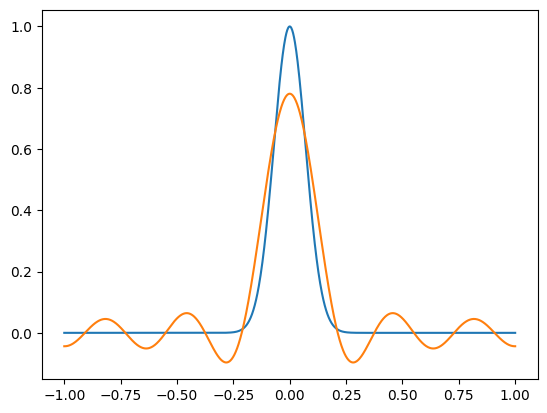

In [5]:
a = 100
N = 1000
x = np.linspace(-1.0, 1.0, N)

y_exact = np.exp(-a * x **2)
y_herm = hermite_expansion(a=a, d=260, n_points=N)

plt.plot(x, y_exact)
plt.plot(x, y_herm) # Not equal

In [6]:
from scipy.special import hermite, roots_hermite
from math import factorial, sqrt, pi

def hermite_expand_gaussian_scaled(a: float,
                                   order: int,
                                   n_points: int = 1000):
    """
    Expand f(x)=exp(-a x^2) on [-1,1] in scaled Hermite polynomials
        H_k(s x) with s = sqrt(a).

    Parameters
    ----------
    a      : positive float   (width parameter)
    order  : number of Hermite terms to keep
    n_points : evaluation grid size

    Returns
    -------
    x  : evaluation grid in [-1,1]
    y  : truncated Hermite series at grid points
    coeffs : array of Hermite coefficients
    """
    if a <= 0:
        raise ValueError("a must be positive.")
    s = np.sqrt(a)                       # scaling factor
    # ------------------------------------------------------------------
    # 1.  coefficient projection with Gauss–Hermite quadrature
    # ------------------------------------------------------------------
    ξ, w = roots_hermite(2 * order)      # high‑accuracy quadrature
    f_vals = np.exp(-ξ**2)               # because u‑variable!
    coeffs = np.empty(order)
    for k in range(order):
        Hk = hermite(k)(ξ)
        # integral in u divided by sqrt(a) (Jacobian)
        coeffs[k] = (w * f_vals * Hk).sum() / (
            2**k * factorial(k) * sqrt(pi) * s
        )
    # ------------------------------------------------------------------
    # 2.  evaluate expansion on physical grid x ∈ [-1,1]
    # ------------------------------------------------------------------
    x = np.linspace(-1, 1, n_points)
    u = s * x                            # scaled argument
    # Clenshaw for stability
    b2 = np.zeros_like(u)
    b1 = np.zeros_like(u)
    for k in range(order - 1, -1, -1):
        b0 = coeffs[k] + 2 * u * b1 - 2 * k * b2
        b2, b1 = b1, b0
    y = b1                                # Hermite series value
    return x, y, coeffs

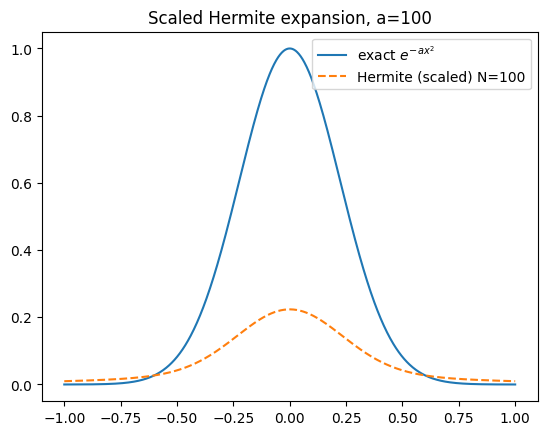

largest |c_k| (k>0): 0.02795084971874783


In [18]:
# ---------------- demo ----------------
a      = 10
order  = 100          # 30 terms are more than enough after scaling
x, y_herm, coeffs = hermite_expand_gaussian_scaled(a, order)

plt.plot(x, np.exp(-a * x**2), label="exact $e^{-a x^2}$")
plt.plot(x, y_herm, "--", label=f"Hermite (scaled) N={order}")
plt.legend()
plt.title("Scaled Hermite expansion, a=100")
plt.show()

print("largest |c_k| (k>0):", np.max(np.abs(coeffs[1:])))